THYROID CANCER RISK — DATA SCIENCE PROJECT

Dataset shape:  212,691 rows x 17 columns

Column dtypes:
Patient_ID               int64
Age                      int64
Gender                     str
Country                    str
Ethnicity                  str
Family_History             str
Radiation_Exposure         str
Iodine_Deficiency          str
Smoking                    str
Obesity                    str
Diabetes                   str
TSH_Level              float64
T3_Level               float64
T4_Level               float64
Nodule_Size            float64
Thyroid_Cancer_Risk        str
Diagnosis                  str
dtype: object

Missing values:
Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     1
Iodine_Deficiency      1
Smoking                1
Obesity                0
Diabetes               1
TSH_Level              0
T3_Level               0
T4_Level       

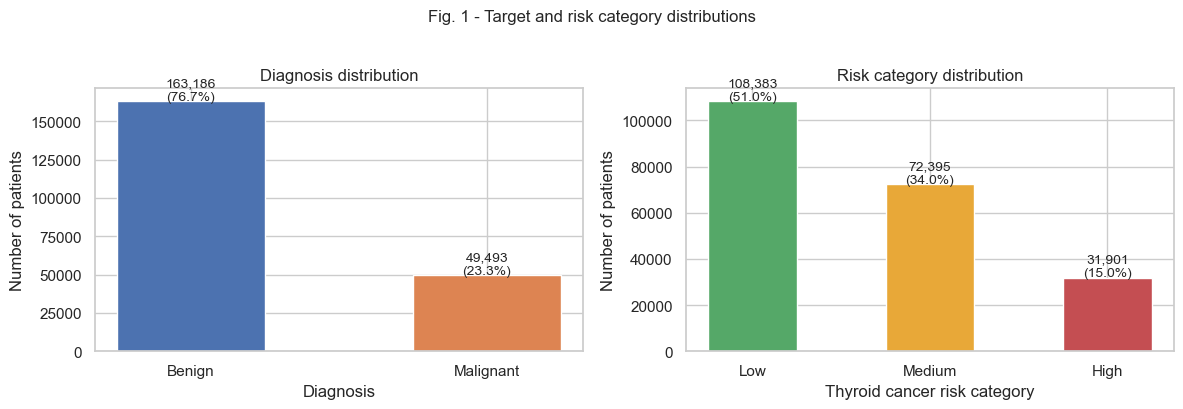

Saved: fig1_distributions.png


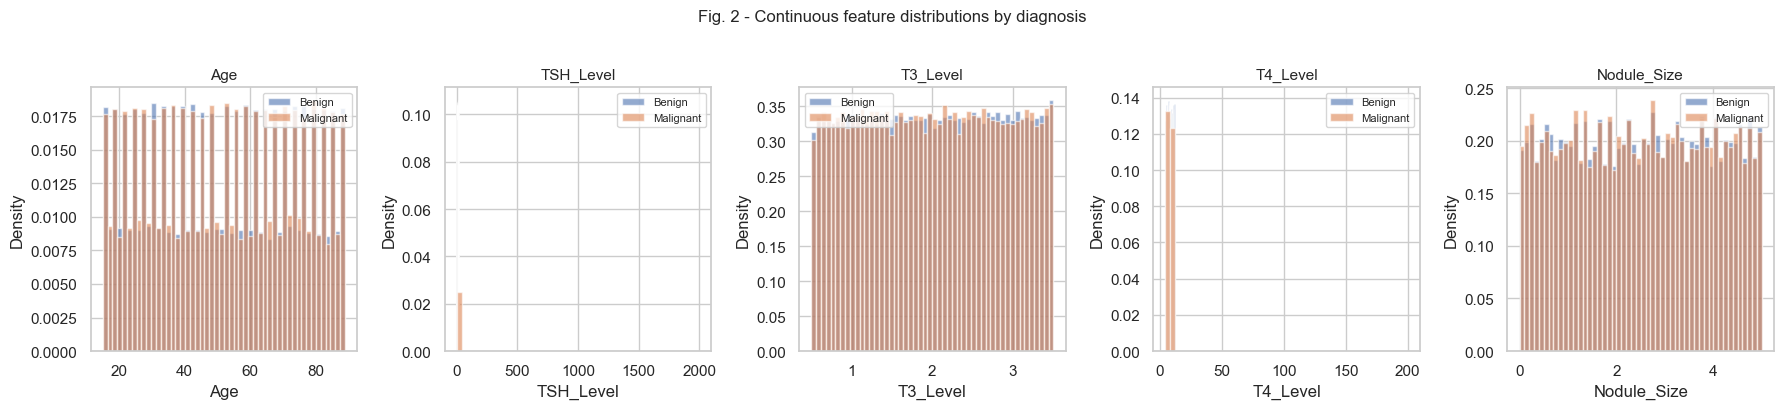

Saved: fig2_continuous_by_diagnosis.png

Mean values of continuous features by diagnosis:
              Age  TSH_Level  T3_Level  T4_Level  Nodule_Size
Diagnosis                                                    
Benign     51.917      5.049     2.003     8.245        2.506
Malignant  51.924      5.071     1.998     8.255        2.496


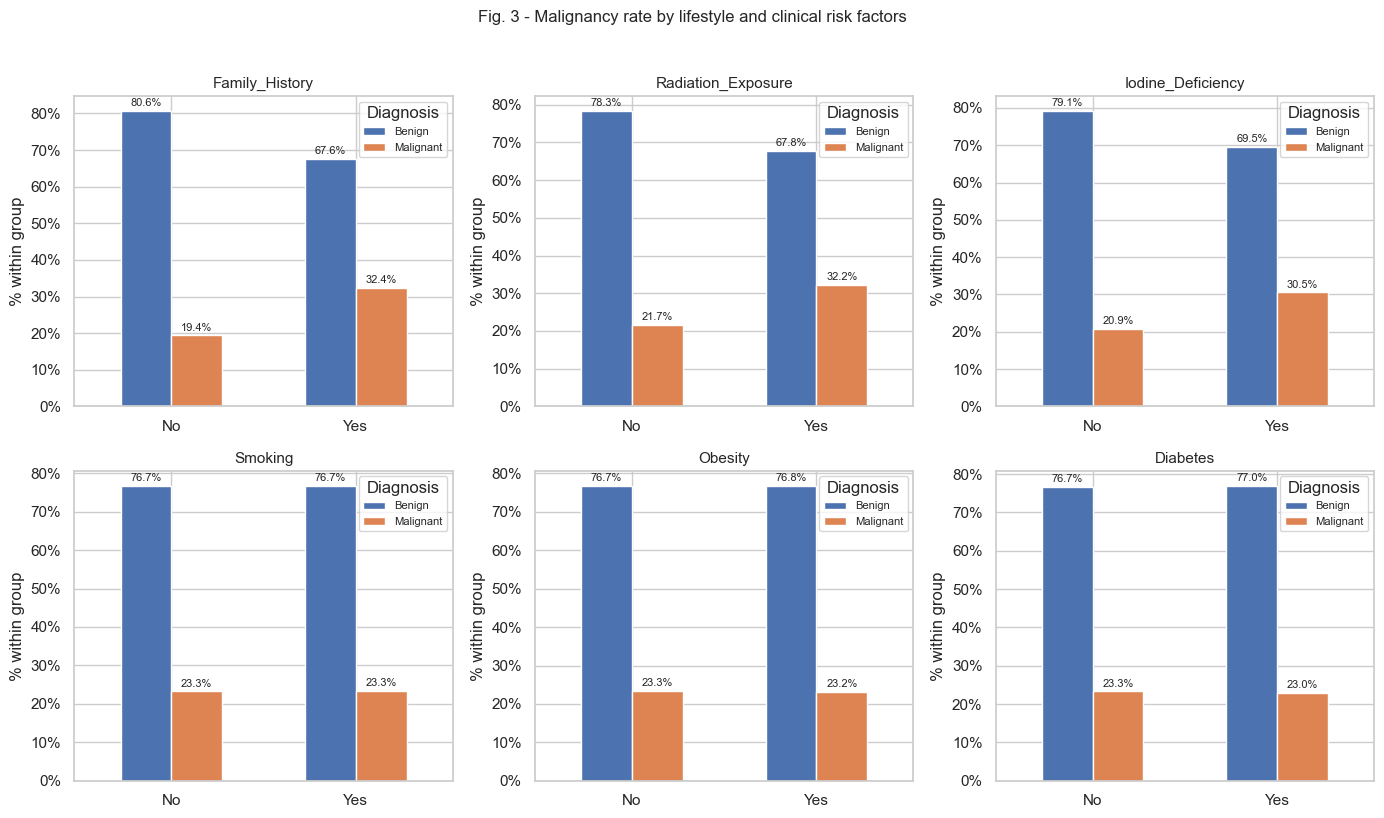

Saved: fig3_binary_features_vs_diagnosis.png


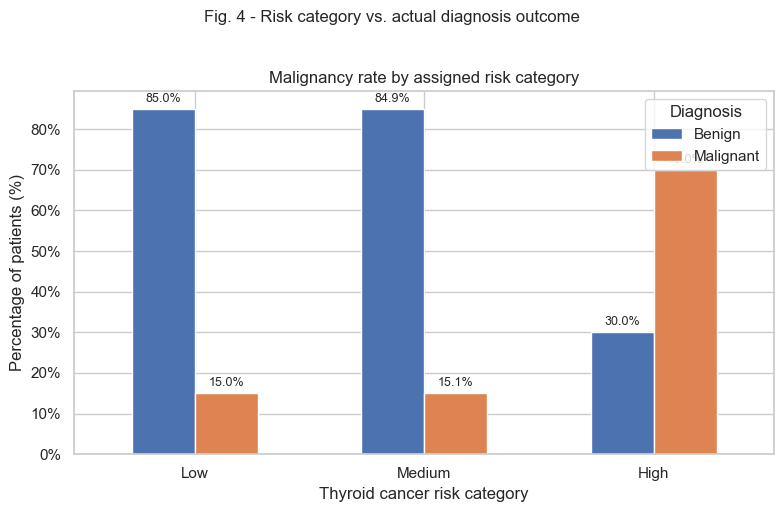

Saved: fig4_risk_category_vs_diagnosis.png


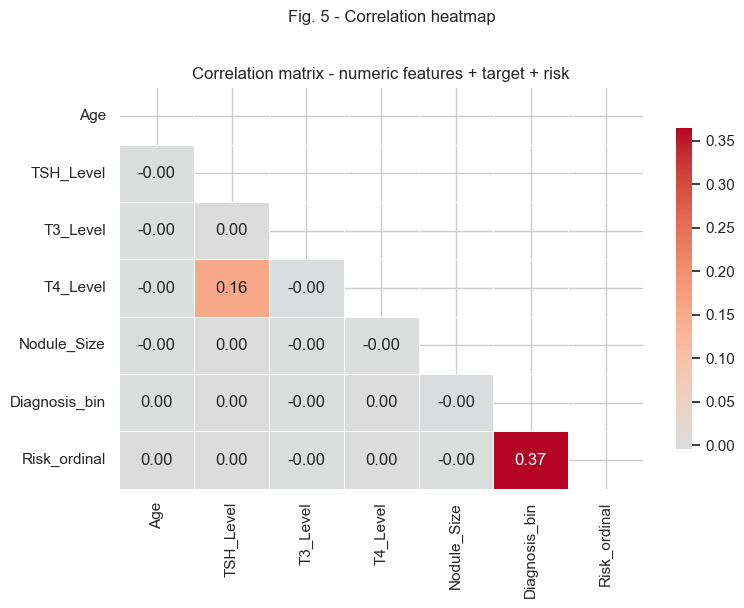

Saved: fig5_correlation_heatmap.png

PREPROCESSING

Features (13): ['Age', 'Gender', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Thyroid_Cancer_Risk']

Class balance:
  Benign:    163,186 (76.7%)
  Malignant: 49,493 (23.3%)

Train: 170,143 | Test: 42,536
Train Malignant rate: 23.3%
Test  Malignant rate: 23.3%

Standardised: ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
(Scaler fitted on training set only — no data leakage into test set)


In [9]:
"""
Thyroid Cancer Risk — Full Analysis Pipeline
Foundations of Data Science Group Project

Research Question:
    Can a machine learning model accurately classify thyroid cancer cases as
    Benign vs. Malignant, and which demographic and clinical risk factors are
    most strongly associated with the diagnosis?

Structure:
    0. Setup & data loading
    1. EDA & visualization
    2. Preprocessing
    3. Statistical testing
    4. Machine learning (Logistic Regression, Random Forest, XGBoost)
    5. Evaluation
    6. Feature importance
    7. Discussion outputs (ablation, naive baseline, accuracy by risk group)

Requirements:
    pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost
"""

# =============================================================================
# 0. SETUP & DATA LOADING
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score, accuracy_score,
)
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not installed — run: pip install xgboost")
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Adjust this path to your CSV location ─────────────────────────────────────
DATA_PATH = "../data/thyroid_cancer_risk_data.csv"


df = pd.read_csv(DATA_PATH)

print("=" * 65)
print("THYROID CANCER RISK — DATA SCIENCE PROJECT")
print("=" * 65)
print(f"\nDataset shape:  {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Drop the 12 rows with missing values (0.006% — negligible)
df.dropna(inplace=True)
print(f"\nAfter dropping nulls: {len(df):,} rows remain")
print(f"\nDiagnosis distribution:\n{df['Diagnosis'].value_counts()}")
print(f"{df['Diagnosis'].value_counts(normalize=True).mul(100).round(1).to_string()} %")


# =============================================================================
# 1. EDA & VISUALIZATION
# =============================================================================

PALETTE     = {"Benign": "#4C72B0", "Malignant": "#DD8452"}
RISK_ORDER  = ["Low", "Medium", "High"]
RISK_COLORS = {"Low": "#55A868", "Medium": "#E8A838", "High": "#C44E52"}

continuous_cols = ["Age", "TSH_Level", "T3_Level", "T4_Level", "Nodule_Size"]
binary_cols     = ["Family_History", "Radiation_Exposure", "Iodine_Deficiency",
                   "Smoking", "Obesity", "Diabetes"]

# ── 1.1 Target and risk category distributions ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

diag_counts = df["Diagnosis"].value_counts()
axes[0].bar(
    diag_counts.index, diag_counts.values,
    color=[PALETTE[k] for k in diag_counts.index],
    edgecolor="white", width=0.5,
)
axes[0].set_title("Diagnosis distribution", fontsize=12)
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Number of patients")
for i, (lbl, val) in enumerate(diag_counts.items()):
    axes[0].text(i, val + 600,
                 f"{val:,}\n({val / len(df) * 100:.1f}%)",
                 ha="center", fontsize=10)

risk_counts = df["Thyroid_Cancer_Risk"].value_counts().reindex(RISK_ORDER)
axes[1].bar(
    risk_counts.index, risk_counts.values,
    color=[RISK_COLORS[r] for r in RISK_ORDER],
    edgecolor="white", width=0.5,
)
axes[1].set_title("Risk category distribution", fontsize=12)
axes[1].set_xlabel("Thyroid cancer risk category")
axes[1].set_ylabel("Number of patients")
for i, (lbl, val) in enumerate(risk_counts.items()):
    axes[1].text(i, val + 600,
                 f"{val:,}\n({val / len(df) * 100:.1f}%)",
                 ha="center", fontsize=10)

fig.suptitle("Fig. 1 - Target and risk category distributions", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_distributions.png")

# ── 1.2 Continuous features by diagnosis ──────────────────────────────────────

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    for label, grp in df.groupby("Diagnosis"):
        ax.hist(grp[col], bins=50, alpha=0.6, label=label,
                color=PALETTE[label], density=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Fig. 2 - Continuous feature distributions by diagnosis",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig2_continuous_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_continuous_by_diagnosis.png")

print("\nMean values of continuous features by diagnosis:")
print(df.groupby("Diagnosis")[continuous_cols].mean().round(3).to_string())

# ── 1.3 Binary/categorical features vs. diagnosis ─────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, binary_cols):
    ct = pd.crosstab(df[col], df["Diagnosis"], normalize="index") * 100
    ct.plot(kind="bar", ax=ax,
            color=[PALETTE["Benign"], PALETTE["Malignant"]],
            edgecolor="white", width=0.55)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("% within group")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Diagnosis", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

fig.suptitle("Fig. 3 - Malignancy rate by lifestyle and clinical risk factors",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig3_binary_features_vs_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_binary_features_vs_diagnosis.png")

# ── 1.4 Risk category alignment with actual diagnosis ─────────────────────────

crosstab_pct = (
    pd.crosstab(df["Thyroid_Cancer_Risk"], df["Diagnosis"], normalize="index")
    .reindex(RISK_ORDER) * 100
)
crosstab_abs = pd.crosstab(
    df["Thyroid_Cancer_Risk"], df["Diagnosis"]
).reindex(RISK_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
crosstab_pct.plot(kind="bar", ax=ax,
                  color=[PALETTE["Benign"], PALETTE["Malignant"]],
                  edgecolor="white", width=0.55)
ax.set_title("Malignancy rate by assigned risk category", fontsize=12)
ax.set_xlabel("Thyroid cancer risk category")
ax.set_ylabel("Percentage of patients (%)")
ax.set_xticklabels(RISK_ORDER, rotation=0)
ax.legend(title="Diagnosis")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

fig.suptitle("Fig. 4 - Risk category vs. actual diagnosis outcome",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig4_risk_category_vs_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_risk_category_vs_diagnosis.png")

# ── 1.5 Correlation heatmap ───────────────────────────────────────────────────

numeric_heatmap = df[continuous_cols].copy()
numeric_heatmap["Diagnosis_bin"] = (df["Diagnosis"] == "Malignant").astype(int)
numeric_heatmap["Risk_ordinal"]  = df["Thyroid_Cancer_Risk"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)

corr = numeric_heatmap.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix - numeric features + target + risk", fontsize=12)
fig.suptitle("Fig. 5 - Correlation heatmap", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_correlation_heatmap.png")


# =============================================================================
# 2. PREPROCESSING
# =============================================================================

print("\n" + "=" * 65)
print("PREPROCESSING")

df_model = df.copy()
df_model.drop(columns=["Patient_ID"], inplace=True)

# Binary Yes/No -> 0/1
for col in binary_cols:
    df_model[col] = (df_model[col] == "Yes").astype(int)

# Gender -> 0/1
df_model["Gender"] = (df_model["Gender"] == "Male").astype(int)

# Thyroid_Cancer_Risk -> ordinal integer (Low=0, Medium=1, High=2)
# Justified: there is a natural clinical ordering from low to high risk.
df_model["Thyroid_Cancer_Risk"] = df_model["Thyroid_Cancer_Risk"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)

# Target -> 0/1
df_model["Diagnosis"] = (df_model["Diagnosis"] == "Malignant").astype(int)

# Drop Country and Ethnicity: high cardinality, no real geographic signal
# in a synthetic dataset. Can be re-added via get_dummies if desired.
df_model.drop(columns=["Country", "Ethnicity"], inplace=True)

X = df_model.drop(columns=["Diagnosis"])
y = df_model["Diagnosis"]
feature_names = X.columns.tolist()

print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"\nClass balance:")
print(f"  Benign:    {(y == 0).sum():,} ({(y == 0).mean() * 100:.1f}%)")
print(f"  Malignant: {(y == 1).sum():,} ({(y == 1).mean() * 100:.1f}%)")

# Stratified 80/20 split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train Malignant rate: {y_train.mean() * 100:.1f}%")
print(f"Test  Malignant rate: {y_test.mean() * 100:.1f}%")

# Standardise continuous features
# Scaler is fitted on training data only — prevents test data leaking into training.
scaler   = StandardScaler()
cont_idx = [feature_names.index(c) for c in continuous_cols]

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

# Convert continuous columns to float so they can hold scaled decimal values
X_train_sc[continuous_cols] = X_train_sc[continuous_cols].astype(float)
X_test_sc[continuous_cols]  = X_test_sc[continuous_cols].astype(float)

# Now assign the scaled values — no type conflict
X_train_sc[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_sc[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print(f"\nStandardised: {continuous_cols}")
print("(Scaler fitted on training set only — no data leakage into test set)")